1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/ToyotaCorolla - MLR.csv")

In [ ]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,4,5,1114


In [ ]:
df.dtypes

,0
Price,int64
Age_08_04,int64
KM,int64
Fuel_Type,object
HP,int64
Automatic,int64
cc,int64
Doors,int64
Cylinders,int64
Gears,int64


In [ ]:
df.shape

(1436, 11)

In [ ]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [ ]:
#Mean price indicates average Toyota Corolla value.
#Standard deviation shows variation in prices.
#Large range between minimum and maximum values indicates possible outliers.
#KM (kilometers driven) may negatively affect price.

In [ ]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


visualization

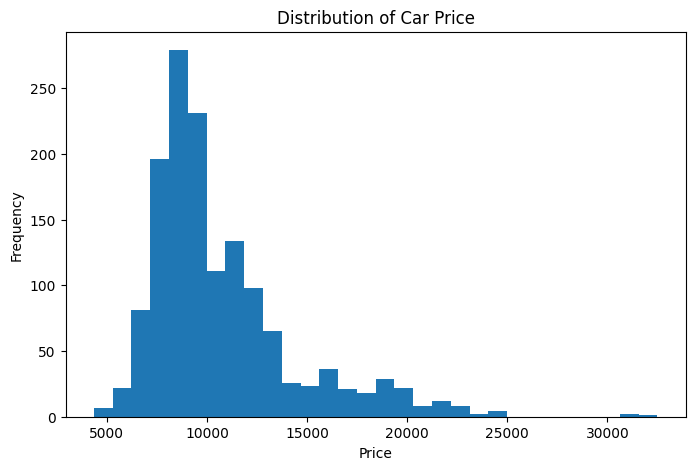

In [ ]:
#histogram
plt.figure(figsize=(8,5))

plt.hist(df['Price'], bins=30)

plt.title('Distribution of Car Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

In [ ]:
#Shows distribution of car prices.
#Helps identify skewness.

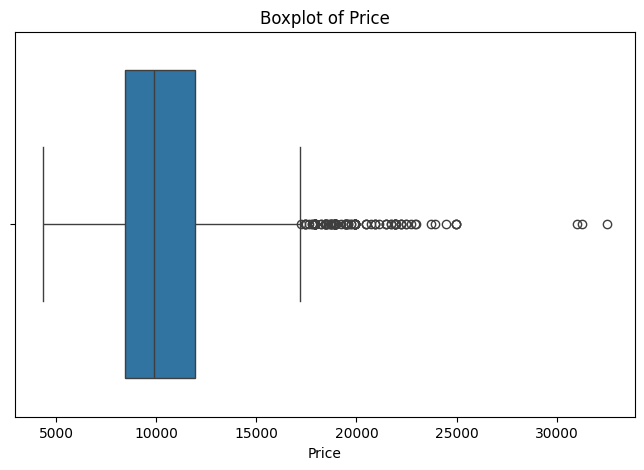

In [ ]:
# Boxplot for Price

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Price'])

plt.title('Boxplot of Price')

plt.show()

In [ ]:
# box plot Detects outliers.
#Outliers may affect regression performance.

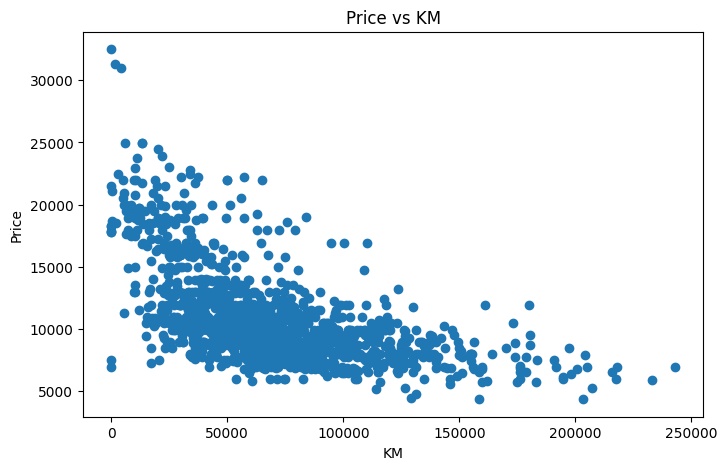

In [ ]:
# Price vs KM

plt.figure(figsize=(8,5))

plt.scatter(df['KM'], df['Price'])

plt.xlabel('KM')
plt.ylabel('Price')

plt.title('Price vs KM')

plt.show()
#Negative relationship usually observed.
#Higher KM reduces car price.

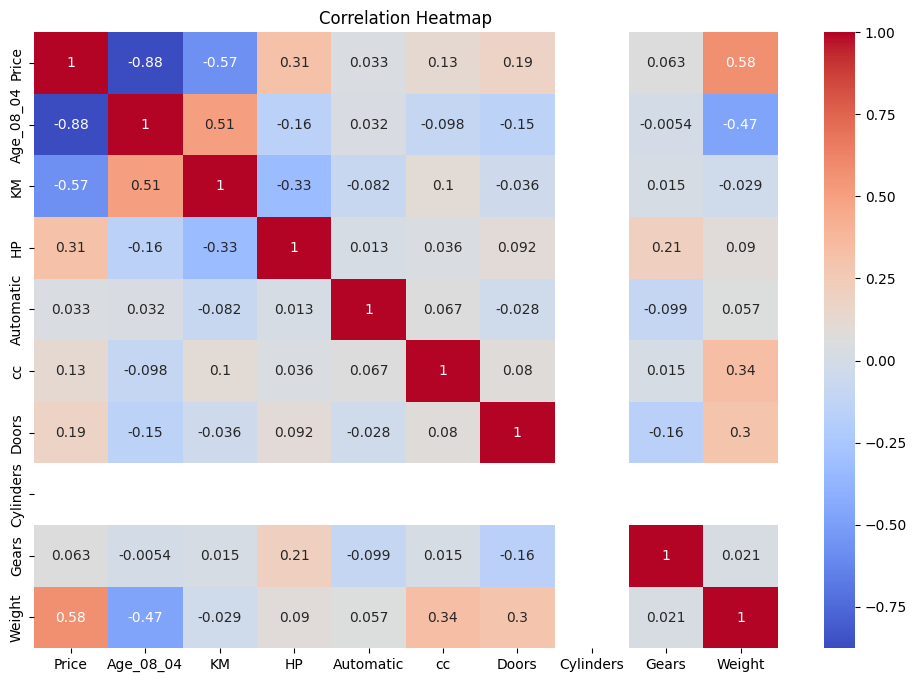

In [ ]:
# Correlation matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()
#positive correlation → variables increase together.
#Negative correlation → one increases while other decreases.
#Strong correlation with Price is important for prediction.

In [ ]:
# Selecting features

X = df[['Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Weight']]

# Target variable

y = df['Price']

2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.


In [ ]:
#linear model
X1 = df[['Age_08_04', 'KM', 'HP']]

y = df['Price']

X1_train, X1_test, y_train, y_test = train_test_split(
    X1,
    y,
    test_size=0.2,
    random_state=42
)

model1 = LinearRegression()

model1.fit(X1_train, y_train)

LinearRegression()

In [ ]:
print(model1.coef_)
print(model1.intercept_)
#Negative coefficient=decreases price.
#Positive coefficient=increases price

[-1.53696216e+02 -1.13134865e-02  3.46719655e+01]
16601.748033810407


In [ ]:
X2 = df[['Age_08_04', 'KM', 'HP', 'cc', 'Weight']]

X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.2,
    random_state=42
)

model2 = LinearRegression()

model2.fit(X2_train, y_train)

LinearRegression()

In [ ]:
X3 = df[['Age_08_04', 'KM', 'HP', 'cc', 'Doors', 'Gears', 'Weight']]

X3_train, X3_test, y_train, y_test = train_test_split(
    X3,
    y,
    test_size=0.2,
    random_state=42
)

model3 = LinearRegression()

model3.fit(X3_train, y_train)

LinearRegression()

In [ ]:
y_pred = model3.predict(X3_test)

4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 995.9885810012298


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1978740.4736284828


In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1406.6771035417057


In [ ]:
#r2_score calculation
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8516996336517375


ridge and lasso

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [ ]:
#ridge model
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

Ridge()

In [ ]:
#ridge prediction
ridge_pred = ridge.predict(X_test)

In [ ]:
#ridge evaluation
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R2 Score:", ridge_r2)

Ridge R2 Score: 0.8516840338430653


In [ ]:
#lasso model
lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

Lasso()

In [ ]:
#lasso prediction
lasso_pred = lasso.predict(X_test)

In [ ]:
#lasso evaluation
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R2 Score:", lasso_r2)

Lasso R2 Score: 0.8516696800453081


In [ ]:
#comapare models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'R2 Score': [r2, ridge_r2, lasso_r2]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.851700
1              Ridge  0.851684
2              Lasso  0.851670


Important Findings
Age and KM have strong negative effects on car price.
HP and Weight positively affect car price.
Multiple Linear Regression predicts price effectively.
Ridge Regression reduces overfitting.
Lasso Regression may remove less important features

interview questions

In [ ]:
'''Both Normalization and Standardization are feature scaling techniques used in Machine Learning and Statistics to transform numerical data into a common scale.

They are important because:

Features may have different units and ranges.
Large-scale features can dominate smaller-scale features.
Many ML algorithms perform better with scaled data.'''

In [ ]:
'''Multicollinearity occurs when:

Independent variables are highly correlated with each other.

Example:

Engine size and horsepower
Weight and fuel consumption'''